In [ ]:


import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from facenet_pytorch import MTCNN, InceptionResnetV1
import supervision as sv



# PATHS


In [ ]:
BASE_DIR = "/content/FaceNet_Project"
DATA_DIR = f"{BASE_DIR}/data_recognition/Karim"
VIDEO_DIR = f"{BASE_DIR}/videos"          # training/test videos


os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)



# LABELS


In [ ]:
classes = {"Karim": 0}
id_to_name = {v: k for k, v in classes.items()}




# MODELS


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
mtcnn = MTCNN(image_size=160, margin=20, device=device)
facenet = InceptionResnetV1(pretrained="vggface2").eval().to(device)



#FACE EXTRACTION


In [ ]:
cap = cv2.VideoCapture(f"{VIDEO_DIR}/karim_train.mp4")
count, skip = 0, 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if skip % 5 == 0:
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        boxes, probs = mtcnn.detect(rgb)

        if boxes is not None and probs is not None:
            for box, prob in zip(boxes, probs):
                if prob < 0.9:
                    continue
                x1, y1, x2, y2 = map(int, box)
                face = frame[y1:y2, x1:x2]
                if face.size == 0:
                    continue
                cv2.imwrite(f"{DATA_DIR}/img_{count}.jpg", face)
                count += 1

    skip += 1

cap.release()
print(f"Saved {count} face images")



Saved 125 face images


# BUILD X_train & y_train


In [ ]:
X_train, y_train = [], []

for img_name in os.listdir(DATA_DIR):
    if img_name.endswith(".jpg"):
        img = cv2.imread(os.path.join(DATA_DIR, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        X_train.append(img)
        y_train.append(classes["Karim"])

# Keep as lists (correct)
y_train = np.array(y_train)




# VISUALIZATION

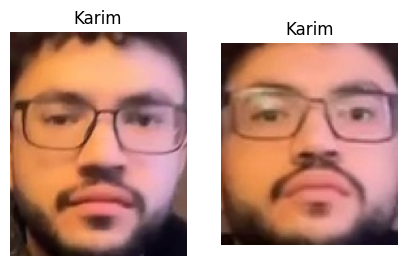

In [ ]:
def ImageClass(n):
    return id_to_name[n]

plt.figure(figsize=(5,5))
for n, i in enumerate(np.random.randint(0, len(X_train), 2)):
    plt.subplot(1, 2, n + 1)
    plt.imshow(X_train[i])
    plt.title(ImageClass(y_train[i]))
    plt.axis("off")
plt.show()



#  EMBEDDINGS


In [ ]:
embeddings, labels = [], []

for img_name in tqdm(os.listdir(DATA_DIR)):
    img = cv2.imread(os.path.join(DATA_DIR, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    face = mtcnn(img)
    if face is not None:
        face = face.unsqueeze(0).to(device)
        emb = facenet(face).detach().cpu().numpy()[0]
        embeddings.append(emb)
        labels.append(classes["Karim"])

df = pd.DataFrame(embeddings)
df["label"] = labels
df.to_csv(f"{BASE_DIR}/embeddings.csv", index=False)

print("Embeddings saved")


100%|██████████| 125/125 [00:11<00:00, 10.66it/s]

Embeddings saved



# COSINE SIMILARITY

In [ ]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


# Video test

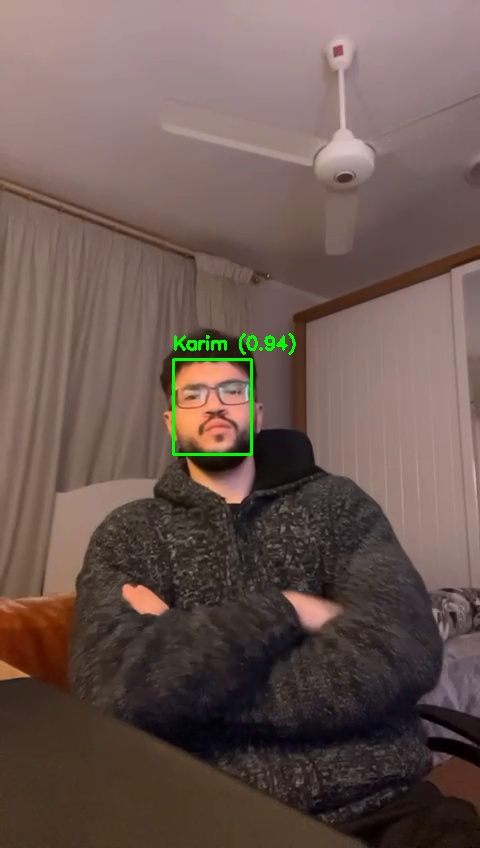

Visual stream stopped.
✅ Finished! You can find the saved video at: /content/FaceNet_Project/visual_result.avi


In [ ]:
import cv2
from IPython.display import display, Image, clear_output
import time

# 1. Load the database we created earlier
data = pd.read_csv(f"{BASE_DIR}/embeddings.csv")
known_embeddings = data.iloc[:, :-1].values

# 2. Open the test video
cap = cv2.VideoCapture(f"{VIDEO_DIR}/karim_test.mp4")

# Get video dimensions for the output file
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# 3. Setup Video Writer to save the result as an .avi file
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out_file = cv2.VideoWriter(f"{BASE_DIR}/visual_result.avi", fourcc, fps, (width, height))

print("Starting Visual Confirmation... (Press the Stop button to interrupt)")

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert to RGB for MTCNN
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        boxes, probs = mtcnn.detect(rgb)

        if boxes is not None:
            for box, prob in zip(boxes, probs):
                if prob < 0.9: continue # Skip low confidence detections

                x1, y1, x2, y2 = map(int, box)

                # Crop face and generate embedding
                face_crop = rgb[max(0, y1):y2, max(0, x1):x2]
                if face_crop.size > 0:
                    face_tensor = mtcnn(face_crop)
                    if face_tensor is not None:
                        face_tensor = face_tensor.unsqueeze(0).to(device)
                        emb = facenet(face_tensor).detach().cpu().numpy()[0]

                        # Compare with our "Karim" database
                        sims = [cosine_similarity(emb, k) for k in known_embeddings]
                        max_sim = max(sims)

                        # Logic: If similarity > 0.65, it's Karim
                        name = "Karim" if max_sim > 0.65 else "Unknown"
                        color = (0, 255, 0) if name == "Karim" else (0, 0, 255)

                        # Draw Box and Label
                        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                        label = f"{name} ({max_sim:.2f})"
                        cv2.putText(frame, label, (x1, y1 - 10),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        # SAVE to file
        out_file.write(frame)

        # --- COLAB VISUAL DISPLAY ---
        # Resize for faster display in notebook if needed
        # frame_disp = cv2.resize(frame, (640, 360))
        _, encoded_img = cv2.imencode('.jpg', frame)

        # Display the frame and clear the previous one to create video effect
        clear_output(wait=True)
        display(Image(data=encoded_img))
        # ----------------------------

except KeyboardInterrupt:
    print("Visual stream stopped.")

finally:
    cap.release()
    out_file.release()
    print(f"✅ Finished! You can find the saved video at: {BASE_DIR}/visual_result.avi")

# live camera

In [ ]:
import base64
import numpy as np
import cv2
import torch
from google.colab import output
from IPython.display import display, Javascript, HTML
import time

# 1. THE INTERFACE (Updated to display text next to the box)
html_interface = """
<div id="container" style="position:relative; width:480px; height:360px;">
    <video id="video" width="480" height="360" autoplay style="display:none;"></video>
    <canvas id="out_canvas" width="480" height="360" style="border:2px solid #333;"></canvas>
</div>
<script>
    var video = document.getElementById('video');
    var canvas = document.getElementById('out_canvas');
    var ctx = canvas.getContext('2d');
    var box = null;

    async function startCamera() {
        const stream = await navigator.mediaDevices.getUserMedia({video: {width: 480, height: 360}});
        video.srcObject = stream;
        await video.play();

        function render() {
            ctx.drawImage(video, 0, 0, canvas.width, canvas.height);
            if(box) {
                let color = (box[4] === "Karim") ? "#00FF00" : "#FF0000";
                ctx.strokeStyle = color;
                ctx.lineWidth = 3;
                // Draw the rectangle
                ctx.strokeRect(box[0], box[1], box[2], box[3]);

                // Draw the Name + Percentage Label
                ctx.fillStyle = color;
                ctx.font = "18px Arial";
                ctx.fillText(box[4] + " (" + box[5] + ")", box[0], box[1] - 10);
            }
            requestAnimationFrame(render);
        }
        render();
    }

    window.getFrame = async function() {
        const tempCanvas = document.createElement('canvas');
        tempCanvas.width = 240;
        tempCanvas.height = 180;
        tempCanvas.getContext('2d').drawImage(video, 0, 0, 240, 180);
        return tempCanvas.toDataURL('image/jpeg', 0.5);
    }

    window.updateBox = function(x, y, w, h, name, score) {
        // box[4] is name, box[5] is the formatted score
        box = [x*2, y*2, w*2, h*2, name, score];
    }

    startCamera();
</script>
"""

def run_final_recognition():
    display(HTML(html_interface))
    time.sleep(2)
    known_embeddings_torch = torch.tensor(known_embeddings).to(device)

    try:
        while True:
            img_data = output.eval_js('window.getFrame()')
            if not img_data: continue

            binary = base64.b64decode(img_data.split(',')[1])
            frame = cv2.imdecode(np.frombuffer(binary, dtype=np.uint8), -1)
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            boxes, _ = mtcnn.detect(rgb)

            if boxes is not None:
                x1, y1, x2, y2 = map(int, boxes[0])
                w, h = x2 - x1, y2 - y1
                face_crop = rgb[max(0, y1):y2, max(0, x1):x2]

                if face_crop.size > 0:
                    face_tensor = mtcnn(face_crop)
                    if face_tensor is not None:
                        with torch.no_grad():
                            emb = facenet(face_tensor.unsqueeze(0).to(device))
                            sims = torch.nn.functional.cosine_similarity(emb, known_embeddings_torch)
                            max_sim = torch.max(sims).item()

                        name = "Karim" if max_sim > 0.65 else "Unknown"
                        # Format score to 2 decimal places (e.g., 0.91)
                        score_str = f"{max_sim:.2f}"

                        # Pass name AND score to JS
                        output.eval_js(f'window.updateBox({x1}, {y1}, {w}, {h}, "{name}", "{score_str}")')
            else:
                output.eval_js('window.box = null;')

    except Exception as e:
        print(f"Stopped: {e}")

run_final_recognition()

KeyboardInterrupt: 